# Calgary development permits: Before-period exploratory review

Review source quality, classification evidence, residential summaries, and the implemented charts for the pinned **Before** snapshot. Reusable analysis and visualization code lives in `dp_activity`.

**Run cells from top to bottom** with the project's Python interpreter and installed plotting/Parquet dependencies. The snapshot contains 16,637 records for August 6, 2022–August 5, 2024. Execution is offline. Charts display in the notebook; optional exports are disabled by default.

Counts describe permit application records, not dwelling units. Only Before coverage is available: **do not interpret an absent During/Post period as zero activity or claim a policy effect**. Seasonal rates are permits per 30 exposed calendar days.

Questions:
- Which fields or classifications require review?
- What are the residential volume, type, processing, and rezoning summaries?
- How does activity vary by month and season within this covered period?
- Which safeguards and comparative visuals still need implementation or additional data?

In [1]:
from pathlib import Path
from datetime import timedelta
from dataclasses import asdict
from io import BytesIO
import hashlib
import json
import sys

import pandas as pd
import matplotlib
from IPython.display import display, Image
from pandas.testing import assert_frame_equal

ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "pyproject.toml").is_file() and (path / "src/dp_activity").is_dir()),
    None,
)
if ROOT is None:
    raise RuntimeError("Open this notebook from within the Data110_DP_Activity repository.")
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from dp_activity.config import load_config
from dp_activity.cli import _default_column_map, _default_classification_field_map, _snapshot_observation_end
from dp_activity.repositories.raw_data_repository import RawDataRepository
from dp_activity.profiling.data_profiler import DataProfiler
from dp_activity.cleaning.permit_cleaner import PermitCleaner
from dp_activity.classification.rule_loader import RuleLoader
from dp_activity.classification.classifier import PermitClassifier
from dp_activity.validation.schema_validator import SchemaValidator
from dp_activity.validation.data_quality_validator import DataQualityValidator
from dp_activity.validation.classification_validator import ClassificationValidator
from dp_activity.features.period_features import add_period_features
from dp_activity.features.season_features import add_season_features
from dp_activity.features.processing_features import add_processing_features
from dp_activity.analysis.volume_analysis import VolumeAnalysis
from dp_activity.analysis.type_analysis import TypeAnalysis
from dp_activity.analysis.processing_analysis import ProcessingAnalysis
from dp_activity.analysis.rezoning_analysis import RezoningAnalysis
from dp_activity.analysis.seasonal_analysis import SeasonalAnalysis
from dp_activity.visualization.chart_factory import ChartFactory
from dp_activity.export.powerbi_exporter import PowerBIExporter
from dp_activity.repositories.output_repository import OutputRepository

pd.set_option("display.max_rows", 15)
pd.set_option("display.max_colwidth", 100)
print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | Matplotlib {matplotlib.__version__}")

Python 3.13.14 | pandas 2.2.3 | Matplotlib 3.10.8


## Select settings and the frozen Before snapshot

Source identity, study dates, paths, and classification options come from `config/settings.yaml`. The explicit filename pins this review to the downloaded Parquet snapshot so a newer download does not silently change the results.

Set `SNAPSHOT_FILENAME` to another frozen snapshot under the configured raw directory when deliberately changing inputs. The notebook verifies its checksum, row count, dataset identity, query dates, and every application date against `study_periods.before`. Missing files or mismatched settings stop execution; no sample is downloaded as a fallback. `REVIEW_LIMIT` limits displayed examples only, not analyzed records.

In [2]:
SETTINGS_PATH = ROOT / "config/settings.yaml"
STUDY_PERIOD_KEY = "before"
SNAPSHOT_FILENAME = "development_permits_raw_Before_2022-08-06_2024-08-05_20260922_001829.parquet"
REVIEW_LIMIT = 10

config = load_config(SETTINGS_PATH)
study_period = config.raw["study_periods"][STUDY_PERIOD_KEY]
snapshot_path = config.raw_data_dir / SNAPSHOT_FILENAME
period_start = pd.Timestamp(study_period["start"])
period_end_exclusive = pd.Timestamp(study_period["end"]) + pd.Timedelta(1, unit="D")
primary_date_field = config.raw["analysis"]["primary_date_field"]
source_date_field = next(
    (source for source, target in _default_column_map().items() if target == primary_date_field),
    None,
)
if source_date_field is None:
    raise ValueError("The configured primary date field has no source-column mapping.")
expected_where = (
    f"({source_date_field} >= '{period_start.date().isoformat()}T00:00:00' AND "
    f"{source_date_field} < '{period_end_exclusive.date().isoformat()}T00:00:00')"
)

display(pd.DataFrame({
    "setting": ["dataset_id", "study_period", "start_inclusive", "end_inclusive",
                "primary_date_field", "rule_file", "raw_formats"],
    "value": [config.raw["data_source"]["dataset_id"], study_period["label"],
              study_period["start"], study_period["end"], primary_date_field,
              str(config.classification_rules_path.relative_to(ROOT)),
              ", ".join(config.raw_snapshot_formats)],
}))

,setting,value
0,dataset_id,6933-unw5
1,study_period,Before
2,start_inclusive,2022-08-06
3,end_inclusive,2024-08-05
4,primary_date_field,applied_date
5,rule_file,config\classification_rules.csv
6,raw_formats,"csv, parquet"


In [3]:
if not snapshot_path.is_file():
    raise FileNotFoundError(
        f"Frozen snapshot not found: {snapshot_path.name}. "
        "Download the selected study period or update SNAPSHOT_FILENAME."
    )
sidecar_path = snapshot_path.with_suffix(snapshot_path.suffix + ".metadata.json")
if not sidecar_path.is_file():
    raise FileNotFoundError("The selected snapshot requires its metadata sidecar.")
print("Using the complete frozen Before snapshot; no network request was made.")
print(f"Selected snapshot: {snapshot_path.relative_to(ROOT)}")

Using the complete frozen Before snapshot; no network request was made.
Selected snapshot: data\raw\development_permits_raw_Before_2022-08-06_2024-08-05_20260922_001829.parquet


## Load and verify provenance

Verify the saved checksum and row count, dataset identity, and download query. Check all application dates against the configured study interval, including its final day. Configuration and rule hashes identify the definitions used for this review; credentials are never displayed.

These checks establish consistency with the saved download, not independent completeness of the City's source. “Raw” means the repository-loaded table before cleaning; consult the snapshot for exact source serialization. CSV loading can infer types and missing-value markers.

In [4]:
repository = RawDataRepository(config.raw_data_dir)
raw = repository.load_snapshot(snapshot_path)
raw_before = raw.copy(deep=True)
digest = hashlib.sha256()
with snapshot_path.open("rb") as stream:
    for chunk in iter(lambda: stream.read(1024 * 1024), b""):
        digest.update(chunk)
snapshot_sha256 = digest.hexdigest()
sidecar_path = snapshot_path.with_suffix(snapshot_path.suffix + ".metadata.json")
metadata = json.loads(sidecar_path.read_text(encoding="utf-8"))
if metadata.get("sha256") != snapshot_sha256:
    raise ValueError("Snapshot checksum differs from its metadata sidecar.")
if metadata.get("row_count") != len(raw):
    raise ValueError("Loaded row count differs from snapshot metadata.")

if metadata.get("dataset_id") != config.raw["data_source"]["dataset_id"]:
    raise ValueError("Snapshot dataset does not match the configured source.")
query = metadata.get("query", {})
if isinstance(query, str):
    query = json.loads(query)
if query.get("where") != expected_where:
    raise ValueError("Snapshot query does not match the configured study period.")
application_dates = pd.to_datetime(raw[source_date_field], errors="raise")
if raw.empty or not (
    application_dates.notna()
    & application_dates.ge(period_start)
    & application_dates.lt(period_end_exclusive)
).all():
    raise ValueError("Snapshot contains missing dates or dates outside the selected study period.")

display(pd.DataFrame([{
    "study_period": study_period["label"],
    "first_application": application_dates.min(),
    "last_application": application_dates.max(),
    "period_verified": True,
    "rows": len(raw),
    "columns": len(raw.columns),
    "snapshot_sha256": snapshot_sha256,
    "checksum_verified": bool(metadata.get("sha256")),
    "retrieved_at_utc": metadata.get("retrieved_at_utc", "unknown"),
    "selection": "Full Before-period download; no sample limit",
    "settings_sha256": hashlib.sha256(SETTINGS_PATH.read_bytes()).hexdigest(),
    "rules_sha256": hashlib.sha256(config.classification_rules_path.read_bytes()).hexdigest(),
}]))
preview_columns = [name for name in ("permitnum", "applieddate", "category", "proposedusedescription", "communityname") if name in raw]
display(raw[preview_columns].head(REVIEW_LIMIT))

,study_period,first_application,last_application,period_verified,rows,columns,snapshot_sha256,checksum_verified,retrieved_at_utc,selection,settings_sha256,rules_sha256
0,Before,2022-08-06,2024-08-05,True,16637,34,649e5e5d95b80003543b03facc372a5beeaea15746687c542f89b52798eded32,True,2026-09-22 00:18:29.189616+00:00,Full Before-period download; no sample limit,7da0cab3bd1dde0b7346aa75a384490107a49039db6138bb32bfb0918db61eb9,2dc55f173351e9caac7e41d0083b464436234b31a1b55b9c5418524ddeb1636c


,permitnum,applieddate,category,proposedusedescription,communityname
0,DP2022-05518,2022-08-07T00:00:00.000,Residential - Secondary Suite,SECONDARY SUITE,CITYSCAPE
1,DP2022-05515,2022-08-07T00:00:00.000,Residential - Secondary Suite,SECONDARY SUITE,SILVER SPRINGS
2,DP2022-05516,2022-08-07T00:00:00.000,Residential - Secondary Suite,BACKYARD SUITE,WHITEHORN
3,DP2022-05517,2022-08-07T00:00:00.000,Residential - Secondary Suite,SECONDARY SUITE,EVANSTON
4,DP2022-05513,2022-08-06T00:00:00.000,Home Occupation Class 2,HOME OCCUPATION - CLASS 2,SANDSTONE VALLEY
5,DP2022-05512,2022-08-06T00:00:00.000,Residential - Secondary Suite,SECONDARY SUITE,SKYVIEW RANCH
6,DP2022-05514,2022-08-06T00:00:00.000,Signs - Permitted Use,SIGN - CLASS B,BELTLINE
7,DP2022-05549,2022-08-09T00:00:00.000,Home Occupation Class 2,HOME OCCUPATION - CLASS 2,TEMPLE
8,DP2022-05550,2022-08-09T00:00:00.000,Change of Use - Permitted Use,RETAIL AND CONSUMER SERVICE,SHAGANAPPI
9,DP2022-05551,2022-08-09T00:00:00.000,Relaxation - Existing - Compliance Follow-Up,DECK,GARRISON WOODS


## Profile the source

Percentages use all loaded rows as the denominator. The profiler counts pandas nulls as missing; blank strings remain evidence until cleaning. Duplicate examples are capped at 20 per identifier field, but counts include all rows. Date bounds in profiler reports are normalized to UTC for comparison and are not policy-period assignments.

In [5]:
profiler = DataProfiler()
source_categories = [
    name for name in ("category", "proposedusedescription", "landusedistrict", "statuscurrent")
    if name in raw
]
raw_profile = profiler.profile(raw, source_categories)
display(raw_profile["summary"])
display(raw_profile["dtypes"])
display(raw_profile["missingness"].sort_values("missing_percentage", ascending=False).head(15))
display(raw_profile["permit_uniqueness"])
display(raw_profile["duplicate_examples"].head(REVIEW_LIMIT))
display(raw_profile["date_ranges"])
for name in source_categories:
    print(f"Source distribution: {name}")
    display(raw_profile[name].head(REVIEW_LIMIT))

,row_count,column_count
0,16637,34


,column,dtype
0,point,object
1,permitnum,object
2,address,object
3,applicant,object
4,category,object
...,...,...
29,canceledrefuseddate,object
30,sdabnumber,object
31,sdabhearingdate,object
32,sdabdecision,object


,column,missing_count,missing_percentage
31,sdabhearingdate,16485,99.086374
32,sdabdecision,16485,99.086374
30,sdabnumber,16484,99.080363
33,sdabdecisiondate,16482,99.068342
29,canceledrefuseddate,13365,80.332993
3,applicant,7945,47.755004
14,releasedate,3895,23.411673
15,mustcommencedate,3225,19.384504
13,decisiondate,3125,18.783435
17,decisionby,3075,18.482900


,column,non_missing_count,unique_count,duplicate_row_count,duplicate_excess_count
0,permitnum,16637,16637,0,0


,column,row_position,permit_number


...

,value,count,percentage
0,SECONDARY SUITE,3858,23.189277
1,SINGLE DETACHED DWELLING,1368,8.222636
2,HOME OCCUPATION - CLASS 2,1223,7.351085
3,SIGN - CLASS B,1149,6.906293
4,DECK,918,5.517822
5,ACCESSORY RESIDENTIAL BUILDING,771,4.634249
6,RETAIL AND CONSUMER SERVICE,342,2.055659
7,GENERAL INDUSTRIAL - LIGHT,290,1.743103
8,MULTI-RESIDENTIAL DEVELOPMENT,275,1.652942
9,CHILD CARE SERVICE,267,1.604857


Source distribution: landusedistrict


,value,count,percentage
0,R-C1,3372,20.268077
1,R-C2,1812,10.891387
2,R-1N,1767,10.620905
3,DC,1587,9.538979
4,I-G,929,5.583939
5,R-CG,871,5.235319
6,R-G,790,4.748452
7,R-1,645,3.876901
8,I-C,299,1.797199
9,R-C1N,298,1.791188


Source distribution: statuscurrent


,value,count,percentage
0,Released,12772,76.768648
1,Cancelled,3017,18.134279
2,In Advertising,255,1.532728
3,Pending Release,173,1.039851
4,Lapsed,113,0.679209
5,Refused,101,0.607081
6,Hold,49,0.294524
7,Inactive,29,0.174310
8,Cancelled - Pending Refund,28,0.168300
9,New,24,0.144257


## Clean and compare

Use the CLI field mappings. The cleaner preserves source values in `raw_*` columns, retains records and index, and flags invalid dates/coordinates. Dates retain source calendar semantics.

Acceptance checks verify that row count, index, and source records remain unchanged. The implemented schema, data-quality, and classification validators run after feature engineering below; their findings do not automatically stop execution.

In [6]:
column_map = _default_column_map()
analysis_settings = config.raw["analysis"]
date_columns = list(dict.fromkeys([
    analysis_settings["primary_date_field"],
    analysis_settings["processing_time"]["end_field"],
]))
cleaner = PermitCleaner(column_map, date_columns)
cleaned = cleaner.clean(raw)
assert_frame_equal(raw, raw_before)
assert len(cleaned) == len(raw)
assert cleaned.index.equals(raw.index)

clean_categories = [column_map.get(name, name) for name in source_categories]
clean_profile = profiler.profile(cleaned, clean_categories)
before_missing = raw_profile["missingness"].copy()
before_missing["column"] = before_missing["column"].replace(column_map)
comparison = before_missing[["column", "missing_count"]].merge(
    clean_profile["missingness"][["column", "missing_count"]],
    on="column", how="left", suffixes=("_before", "_after"),
)
comparison["change"] = comparison["missing_count_after"] - comparison["missing_count_before"]
display(comparison.sort_values("change", ascending=False).head(15))
invalid_columns = [name for name in cleaned.columns if name.endswith("_invalid")]
display(cleaned[invalid_columns].sum().rename("flagged_rows").to_frame())
print(f"Preserved {len(cleaned)} records and the original row index.")

,column,missing_count_before,missing_count_after,change
0,point,25,25,0
1,permit_number,0,0,0
2,address,1,1,0
3,applicant,7945,7945,0
4,category,7,7,0
5,description,0,0,0
6,proposed_use_code,0,0,0
7,proposed_use_description,0,0,0
8,permitteddiscretionary,0,0,0
9,land_use_district,0,0,0


,flagged_rows
applied_date_invalid,0
decision_date_invalid,0
latitude_invalid,0
longitude_invalid,0


Preserved 16637 records and the original row index.


## Classify with the configured rule file

The first enabled rule in priority/ID order wins. Later matches are retained as potential overlaps. Broad fallback and catch-all rules intentionally overlap specific rules; overlap counts alone do not establish a classification error.

Unmatched records and winners labelled provisional, fallback, or review require manual review. A rule's validation label is not independent proof that the classification is correct.

In [7]:
rules = RuleLoader().load(config.classification_rules_path)
classification_settings = analysis_settings["classification"]
classifier = PermitClassifier(
    rules,
    _default_classification_field_map(),
    unmatched_action=classification_settings["unmatched_action"],
    case_sensitive=classification_settings["case_sensitive"],
)
cleaned_before = cleaned.copy(deep=True)
classified = classifier.classify(cleaned)
coverage = classifier.coverage_report(classified)
assert_frame_equal(cleaned, cleaned_before)
assert len(classified) == len(raw)
assert int(coverage["record_count"].sum()) == len(raw)

display(pd.DataFrame([{
    "enabled_rules": len(rules),
    "records": len(classified),
    "matched": int(classified["ClassificationRule"].notna().sum()),
    "unmatched": int(classified["ClassificationRule"].isna().sum()),
    "needs_review": int(classified["ClassificationNeedsReview"].sum()),
    "overlapping_matches": int(classified["ClassificationConflictCount"].gt(0).sum()),
    "included_residential": int(classified["IncludeResidential"].sum()),
}]))
display(coverage.sort_values("record_count", ascending=False).head(15))
display(classified.groupby(
    ["ResidentialType", "IncludeResidential", "ValidationStatus"], dropna=False
).size().rename("records").reset_index().sort_values("records", ascending=False).head(15))

,enabled_rules,records,matched,unmatched,needs_review,overlapping_matches,included_residential
0,34,16637,16632,5,1101,15914,7940


,ClassificationRule,ValidationStatus,ClassificationNeedsReview,record_count,matched_count,unmatched_count,conflict_count,additional_match_count,record_percentage
0,HF-016,validated_2026_sample,False,3831,3831,0,3831,15345,23.026988
4,HF-905,validated_2026_sample,False,2529,2529,0,2529,2529,15.201058
12,HF-010,validated_2026_sample,False,1856,1856,0,1856,6954,11.155857
3,HF-900,validated_2026_sample,False,1845,1845,0,1845,1845,11.089740
2,HF-901,validated_2026_sample,False,1224,1224,0,1224,1224,7.357096
5,HF-906,validated_2026_sample,False,1103,1103,0,1103,1103,6.629801
10,HF-018,validated_2026_sample,False,814,814,0,814,1641,4.892709
8,HF-999,review,True,718,718,0,0,0,4.315682
16,HF-005,validated_2026_sample,False,482,482,0,482,2643,2.897157
17,HF-012,validated_2026_sample,False,418,418,0,418,1753,2.512472


,ResidentialType,IncludeResidential,ValidationStatus,records
6,Non-Residential,False,validated_2026_sample,5793
14,Secondary Suite,True,validated_2026_sample,3846
16,Single Detached,True,validated_2026_sample,2313
11,Residential Non-Housing,False,validated_2026_sample,1103
1,Accessory Residential Building,False,validated_2026_sample,814
19,Unclassified,False,review,718
15,Semi-Detached,True,validated_2026_sample,525
4,Multi-Residential,True,validated_2026_sample,447
2,Backyard Suite,True,validated_2026_sample,355
13,Rowhouse,True,validated_2026_sample,323


## Inspect review cases and rule coverage

Examples use source order and are not a randomized validation sample. Read source evidence, the winning rule, and later matches before proposing changes. Zero winning counts may indicate shadowing or absence from this full Before snapshot; they do not by themselves justify deleting a rule.

In [8]:
review_columns = [name for name in (
    "permit_number", "category", "proposed_use_description", "description",
    "raw_category", "raw_proposed_use_description", "ClassificationRule",
    "ValidationStatus", "ResidentialType", "ClassificationNeedsReview",
    "ClassificationMatchedRules",
) if name in classified]
for label, mask in {
    "Unmatched": classified["ClassificationRule"].isna(),
    "Needs review": classified["ClassificationNeedsReview"],
    "Potential overlaps": classified["ClassificationConflictCount"].gt(0),
}.items():
    print(f"{label}: {int(mask.sum())} records; showing at most {REVIEW_LIMIT}.")
    display(classified.loc[mask, review_columns].head(REVIEW_LIMIT))

winning_counts = classified["ClassificationRule"].value_counts()
all_match_counts = classified["ClassificationMatchedRules"].explode().dropna().value_counts()
rule_coverage = pd.DataFrame([{
    "rule_id": rule.rule_id, "priority": rule.priority, "field": rule.field,
    "match_value": rule.match_value, "validation_status": rule.validation_status,
    "winning_records": int(winning_counts.get(rule.rule_id, 0)),
    "all_matching_records": int(all_match_counts.get(rule.rule_id, 0)),
} for rule in rules])
display(rule_coverage)
display(raw_profile["description_examples"].head(REVIEW_LIMIT))

Unmatched: 5 records; showing at most 10.


,permit_number,category,proposed_use_description,description,raw_category,raw_proposed_use_description,ClassificationRule,ValidationStatus,ResidentialType,ClassificationNeedsReview,ClassificationMatchedRules
433,DP2022-05985,None,VEHICLE SALES - MAJOR,CHANGE OF USE: VEHICLE SALES - MAJOR,None,VEHICLE SALES - MAJOR,<NA>,unmatched,Review,True,()
2534,DP2022-08287,None,RETAIL AND CONSUMER SERVICE,CHANGE OF USE: RETAIL AND CONSUMER SERVICE,None,RETAIL AND CONSUMER SERVICE,<NA>,unmatched,Review,True,()
9474,DP2023-07200,None,BUILDING SUPPLY CENTRE,CHANGE OF USE: BUILDING SUPPLY CENTRE,None,BUILDING SUPPLY CENTRE,<NA>,unmatched,Review,True,()
9981,DP2023-07748,None,HEALTH CARE SERVICE,REVISION: HEALTH CARE SERVICE (CHANGE OF USE TO DP2020-3951),None,HEALTH CARE SERVICE,<NA>,unmatched,Review,True,()
14595,DP2024-03548,None,BED AND BREAKFAST,: BED AND BREAKFAST,None,BED AND BREAKFAST,<NA>,unmatched,Review,True,()


Needs review: 1101 records; showing at most 10.


,permit_number,category,proposed_use_description,description,raw_category,raw_proposed_use_description,ClassificationRule,ValidationStatus,ResidentialType,ClassificationNeedsReview,ClassificationMatchedRules
12,DP2022-05555,Commercial - Other Areas,CAR WASH - MULTI-VEHICLE,NEW: CAR WASH - MULTI-VEHICLE,Commercial - Other Areas,CAR WASH - MULTI-VEHICLE,HF-902,fallback,Non-Residential,True,"(HF-902, HF-999)"
14,DP2022-05519,Temporary Structure,POST-SECONDARY LEARNING INSTITUTION,TEMPORARY USE: POST-SECONDARY LEARNING INSTITUTION (RECREATIONAL FACILITY BUILDING - TEN YEARS),Temporary Structure,POST-SECONDARY LEARNING INSTITUTION,HF-999,review,Unclassified,True,"(HF-999,)"
40,DP2022-05557,Commercial - Other Areas,CHILD CARE SERVICE; LIQUOR STORE; RETAIL AND CONSUMER SERVICE,"NEW: LIQUOR STORE, CHILD CARE SERVICE, RETAIL AND CONSUMER SERVICE (6 PHASES, 5 BUILDINGS)",Commercial - Other Areas,CHILD CARE SERVICE; LIQUOR STORE; RETAIL AND CONSUMER SERVICE,HF-902,fallback,Non-Residential,True,"(HF-902, HF-999)"
48,DP2022-05564,Renovations - Non-Residential,DECK,REVISION: MULTI-RESIDENTIAL (DECK),Renovations - Non-Residential,DECK,HF-999,review,Unclassified,True,"(HF-999,)"
82,DP2022-05602,Renovations - Non-Residential,GENERAL INDUSTRIAL - LIGHT,EXTERIOR RENOVATIONS: GENERAL INDUSTRIAL - LIGHT (REFURBISH BUILDING FAÇADE),Renovations - Non-Residential,GENERAL INDUSTRIAL - LIGHT,HF-999,review,Unclassified,True,"(HF-999,)"
89,DP2022-05613,Commercial - Other Areas,RETAIL AND CONSUMER SERVICE; VETERINARY CLINIC,"NEW: VETERINARY CLINIC, RETAIL AND CONSUMER SERVICE (1 BUILDING)",Commercial - Other Areas,RETAIL AND CONSUMER SERVICE; VETERINARY CLINIC,HF-902,fallback,Non-Residential,True,"(HF-902, HF-999)"
91,DP2022-05614,Temporary Structure,GENERAL INDUSTRIAL - LIGHT,TEMPORARY USE: GENERAL INDUSTRIAL - LIGHT (STORAGE TENT) - 5 YEARS,Temporary Structure,GENERAL INDUSTRIAL - LIGHT,HF-999,review,Unclassified,True,"(HF-999,)"
121,DP2022-05630,Development Design Guidelines,TEMPORARY RESIDENTIAL SALES CENTRE,TEMPORARY USE: TEMPORARY RESIDENTIAL SALES CENTRE (3 UNITS) - 2 YEARS,Development Design Guidelines,TEMPORARY RESIDENTIAL SALES CENTRE,HF-999,review,Unclassified,True,"(HF-999,)"
133,DP2022-05659,Temporary Structure,TEMPORARY RESIDENTIAL SALES CENTRE,TEMPORARY USE: TEMPORARY RESIDENTIAL SALES CENTRE (4 YEARS),Temporary Structure,TEMPORARY RESIDENTIAL SALES CENTRE,HF-999,review,Unclassified,True,"(HF-999,)"
154,DP2022-05680,Renovations - Non-Residential,"BREWERY, WINERY AND DISTILLERY; OUTDOOR CAFE; RESTAURANT: LICENSED","EXTERIOR RENOVATIONS: BREWERY, WINERY AND DISTILLERY, RESTAURANT: LICENSED (NEW GARAGE DOOR); RE...",Renovations - Non-Residential,"BREWERY, WINERY AND DISTILLERY; OUTDOOR CAFE; RESTAURANT: LICENSED",HF-999,review,Unclassified,True,"(HF-999,)"


Potential overlaps: 15914 records; showing at most 10.


,permit_number,category,proposed_use_description,description,raw_category,raw_proposed_use_description,ClassificationRule,ValidationStatus,ResidentialType,ClassificationNeedsReview,ClassificationMatchedRules
0,DP2022-05518,Residential - Secondary Suite,SECONDARY SUITE,NEW: SECONDARY SUITE (BASEMENT) - PARKING STALL SIZE,Residential - Secondary Suite,SECONDARY SUITE,HF-016,validated_2026_sample,Secondary Suite,False,"(HF-016, HF-017, HF-102, HF-106, HF-999)"
1,DP2022-05515,Residential - Secondary Suite,SECONDARY SUITE,NEW: SECONDARY SUITE (BASEMENT),Residential - Secondary Suite,SECONDARY SUITE,HF-016,validated_2026_sample,Secondary Suite,False,"(HF-016, HF-017, HF-102, HF-106, HF-999)"
2,DP2022-05516,Residential - Secondary Suite,BACKYARD SUITE,NEW: BACKYARD SUITE (CONVERTING EXISTING GARAGE),Residential - Secondary Suite,BACKYARD SUITE,HF-014,validated_2026_sample,Backyard Suite,False,"(HF-014, HF-015, HF-102, HF-106, HF-999)"
3,DP2022-05517,Residential - Secondary Suite,SECONDARY SUITE,NEW: SECONDARY SUITE (BASEMENT),Residential - Secondary Suite,SECONDARY SUITE,HF-016,validated_2026_sample,Secondary Suite,False,"(HF-016, HF-017, HF-102, HF-106, HF-999)"
4,DP2022-05513,Home Occupation Class 2,HOME OCCUPATION - CLASS 2,TEMPORARY USE: HOME OCCUPATION - CLASS 2 (MOTOR VEHICLE DEALER - 18 MONTHS),Home Occupation Class 2,HOME OCCUPATION - CLASS 2,HF-901,validated_2026_sample,Non-Residential,False,"(HF-901, HF-999)"
5,DP2022-05512,Residential - Secondary Suite,SECONDARY SUITE,NEW: SECONDARY SUITE (BASEMENT),Residential - Secondary Suite,SECONDARY SUITE,HF-016,validated_2026_sample,Secondary Suite,False,"(HF-016, HF-017, HF-102, HF-106, HF-999)"
6,DP2022-05514,Signs - Permitted Use,SIGN - CLASS B,NEW: SIGN - CLASS B (FASCIA SIGN),Signs - Permitted Use,SIGN - CLASS B,HF-900,validated_2026_sample,Non-Residential,False,"(HF-900, HF-999)"
7,DP2022-05549,Home Occupation Class 2,HOME OCCUPATION - CLASS 2,TEMPORARY USE: HOME OCCUPATION - CLASS 2 (AESTHETICS - 18 MONTHS),Home Occupation Class 2,HOME OCCUPATION - CLASS 2,HF-901,validated_2026_sample,Non-Residential,False,"(HF-901, HF-999)"
8,DP2022-05550,Change of Use - Permitted Use,RETAIL AND CONSUMER SERVICE,REVISION: RETAIL AND CONSUMER SERVICE (CHANGE OF USE TO DP2016-4510),Change of Use - Permitted Use,RETAIL AND CONSUMER SERVICE,HF-905,validated_2026_sample,Non-Residential,False,"(HF-905, HF-999)"
9,DP2022-05551,Relaxation - Existing - Compliance Follow-Up,DECK,RELAXATION: PRIVACY WALL (EXISTING) - HEIGHT,Relaxation - Existing - Compliance Follow-Up,DECK,HF-906,validated_2026_sample,Residential Non-Housing,False,"(HF-906, HF-999)"


,rule_id,priority,field,match_value,validation_status,winning_records,all_matching_records
0,HF-001,10,proposedusedescription,ROWHOUSE BUILDING,validated_2026_sample,282,282
1,HF-002,11,description,ROWHOUSE,validated_2026_sample,41,315
2,HF-003,20,proposedusedescription,TOWNHOUSE,provisional,54,60
3,HF-004,21,description,TOWNHOUSE,validated_2026_sample,7,72
4,HF-005,30,proposedusedescription,SEMI-DETACHED DWELLING,validated_2026_sample,482,494
...,...,...,...,...,...,...,...
29,HF-903,903,category,Industrial,validated_2026_sample,137,137
30,HF-904,904,category,Mixed Use,validated_2026_sample,58,84
31,HF-905,905,category,Change of Use,validated_2026_sample,2529,2588
32,HF-906,906,category,Relaxation,validated_2026_sample,1103,2892


,column,row_position,description,character_count
0,description,2913,REVISION: ASSISTED LIVING (PARKING & MECHANICAL EQUIPMENT) - 60(1)(C) ALL ELECTRICAL AND MECHANI...,416
1,description,4157,"REVISION: RETAIL AND CONSUMER SERVICE, CHILD CARE SERVICE (168 CHILDREN, OUTDOOR PLAY AREA) HEAL...",410
2,description,14707,RELAXATION: SINGLE DETACHED DWELLING (EXISTING) - BUILDING SETBACK FROM SIDE & REAR PROPERTY LIN...,390
3,description,9815,CHANGE OF USE: RESTAURANT (2) (WITHIN EXISTING AUTOMOTIVE SERVICE); EXTERIOR RENOVATIONS: AUTOMO...,369
4,description,534,"CHANGE OF USE: BREWERY, WINERY AND DISTILLERY; EXTERIOR RENOVATIONS: BREWERY, WINERY AND DISTILL...",329
5,description,14551,"RELAXATION: SINGLE DETACHED DWELLING (EXISTING) - BUILDING SETBACK FROM SIDE PROPERTY LINE, ACCE...",320
6,description,4935,CHANGE OF USE: SINGLE DETACHED DWELLING; RELAXATION: SINGLE DETACHED DWELLING (EXISTING) - BUILD...,316
7,description,4931,CHANGES TO SITE PLAN: CHANGE OF USE: DWELLING UNITS; EXTERIOR RENOVATIONS: MULTI-RESIDENTIAL DEV...,306
8,description,3476,"RELAXATION: SINGLE DETACHED DWELLING (EXISTING) BUILDING SETBACK FROM SIDE & REAR PROPERTY LINE,...",292
9,description,6607,"NEW: RETAIL AND CONSUMER SERVICE, FINANCIAL INSTITUTION, CHILD CARE SERVICE (208 CHILDREN), REST...",283


## Derive period, season, and processing features

Apply the pure feature filters in pipeline order, using configured dates, season labels/months, and minimum processing days. The snapshot retrieval date in UTC is the explicit inclusive observation horizon for this exploratory review; it is a date-level convention, not proof that every source record is current through that date.

Period assignment follows application dates; decision periods and boundary-crossing flags are separate evidence. Complete seasons must fit within one policy window and the observation horizon. Processing durations remain signed, and summaries include only `HasValidProcessingDays` records. Missing decisions are an analytical pending/censoring proxy, not an official status. These descriptive tables cover all loaded permits, not just the residential subset.

In [9]:
classified_before_features = classified.copy(deep=True)
observation_end = _snapshot_observation_end(snapshot_path, None)
processing_settings = analysis_settings["processing_time"]
feature_periods = list(config.periods)

period_permits = add_period_features(
    classified,
    date_column=analysis_settings["primary_date_field"],
    periods=feature_periods,
    decision_date_column=processing_settings["end_field"],
)
season_permits = add_season_features(
    period_permits,
    date_column=analysis_settings["primary_date_field"],
    season_months={
        value.get("label", key): value["months"]
        for key, value in config.raw["seasons"].items()
    },
    analysis_windows=feature_periods,
    observation_end=observation_end,
)
featured = add_processing_features(
    season_permits,
    applied_date_column=processing_settings["start_field"],
    decision_date_column=processing_settings["end_field"],
    minimum_days=processing_settings.get("minimum_days", 0),
    observation_end=observation_end,
)
assert_frame_equal(classified, classified_before_features)
assert_frame_equal(featured[classified.columns], classified)
assert_frame_equal(season_permits[period_permits.columns], period_permits)
assert_frame_equal(featured[season_permits.columns], season_permits)
assert len(featured) == len(raw) and featured.index.equals(raw.index)
assert featured["Period"].eq(study_period["label"]).all()

print(f"Observation horizon (snapshot retrieval date, UTC): {observation_end}")
print("Period counts: all loaded permit records.")
display(featured.groupby("Period", observed=True, dropna=False).size().rename("records").to_frame())
print("Decision-period boundary crossings; missing means not assessable.")
display(featured["CrossesPeriodBoundary"].value_counts(dropna=False).rename("records").to_frame())
season_summary = featured.groupby(
    ["Period", "SeasonSortKey", "SeasonLabel", "SeasonStartDate", "SeasonEndDate",
     "IsCompleteSeason", "IsPartialSeason"], observed=True, dropna=False,
).size().rename("records").reset_index().sort_values("SeasonSortKey")
assert int(season_summary["records"].sum()) == len(featured)
display(season_summary)

processing_flags = [
    "HasValidProcessingDays", "HasNegativeProcessingDays", "IsPending",
    "IsRightCensored", "ProcessingDateMissing", "ProcessingDateInvalid", "IsAfterObservationEnd",
]
print("Processing flags: overlapping counts, not mutually exclusive groups.")
display(featured[processing_flags].sum().rename("records").to_frame())
valid_durations = featured.loc[featured["HasValidProcessingDays"], "ProcessingDays"]
print("Calendar-day duration summary: valid records only, all permit types.")
display(valid_durations.describe(percentiles=[0.25, 0.5, 0.75]).to_frame("days"))
display(pd.DataFrame([{
    "total_records": len(featured),
    "valid_duration_records": len(valid_durations),
    "excluded_duration_records": len(featured) - len(valid_durations),
    "known_follow_up_records": int(featured["FollowUpDays"].notna().sum()),
    "observation_end": observation_end,
}]))
display(featured[[
    "permit_number", "Period", "DecisionPeriod", "CrossesPeriodBoundary",
    "SeasonLabel", "IsCompleteSeason", "ProcessingDays", "HasValidProcessingDays",
    "IsPending", "IsRightCensored", "FollowUpDays",
]].head(REVIEW_LIMIT))

Observation horizon (snapshot retrieval date, UTC): 2026-09-22
Period counts: all loaded permit records.


,records
Period,
Before,16637


Decision-period boundary crossings; missing means not assessable.


,records
CrossesPeriodBoundary,
False,12346
<NA>,3125
True,1166


,Period,SeasonSortKey,SeasonLabel,SeasonStartDate,SeasonEndDate,IsCompleteSeason,IsPartialSeason,records
0,Before,202206,Summer 2022,2022-06-01,2022-08-31,False,True,607
1,Before,202209,Fall 2022,2022-09-01,2022-11-30,True,False,1844
2,Before,202212,Winter 2022–23,2022-12-01,2023-02-28,True,False,1653
3,Before,202303,Spring 2023,2023-03-01,2023-05-31,True,False,2098
4,Before,202306,Summer 2023,2023-06-01,2023-08-31,True,False,2327
5,Before,202309,Fall 2023,2023-09-01,2023-11-30,True,False,2110
6,Before,202312,Winter 2023–24,2023-12-01,2024-02-29,True,False,2011
7,Before,202403,Spring 2024,2024-03-01,2024-05-31,True,False,2252
8,Before,202406,Summer 2024,2024-06-01,2024-08-31,False,True,1735


...

,records
HasValidProcessingDays,13512
HasNegativeProcessingDays,0
IsPending,3125
IsRightCensored,3125
ProcessingDateMissing,3125
ProcessingDateInvalid,0
IsAfterObservationEnd,0


Calendar-day duration summary: valid records only, all permit types.


,days
count,13512.0
mean,61.929618
std,83.178295
min,0.0
25%,19.0
50%,38.0
75%,67.0
max,1195.0


,total_records,valid_duration_records,excluded_duration_records,known_follow_up_records,observation_end
0,16637,13512,3125,16637,2026-09-22


,permit_number,Period,DecisionPeriod,CrossesPeriodBoundary,SeasonLabel,IsCompleteSeason,ProcessingDays,HasValidProcessingDays,IsPending,IsRightCensored,FollowUpDays
0,DP2022-05518,Before,Before,False,Summer 2022,False,24,True,False,False,24
1,DP2022-05515,Before,Before,False,Summer 2022,False,26,True,False,False,26
2,DP2022-05516,Before,Before,False,Summer 2022,False,61,True,False,False,61
3,DP2022-05517,Before,Before,False,Summer 2022,False,33,True,False,False,33
4,DP2022-05513,Before,Before,False,Summer 2022,False,51,True,False,False,51
5,DP2022-05512,Before,Before,False,Summer 2022,False,48,True,False,False,48
6,DP2022-05514,Before,Before,False,Summer 2022,False,12,True,False,False,12
7,DP2022-05549,Before,Before,False,Summer 2022,False,40,True,False,False,40
8,DP2022-05550,Before,Before,False,Summer 2022,False,8,True,False,False,8
9,DP2022-05551,Before,Before,False,Summer 2022,False,6,True,False,False,6


## Validate schema, data quality, and classification

Run the reusable validation strategies against the full feature-enriched table. Required columns and quality options come from `config/settings.yaml`; classification validation uses the same loaded rules as the classifier. Schema and quality result objects are converted to display tables without changing their meaning.

Additional source and derived columns are informational. Missing prerequisites and inconsistent audit fields are failures; missing values and review cases may be warnings. Findings remain visible for investigation and do not remove records or automatically stop the notebook. Optional size/freshness checks run only when configured; freshness uses an explicit reference date suitable for the study window.

No independent human-labelled audit sample is supplied here, so accuracy remains unknown and no confusion matrix is produced. Coverage and rule status labels do not establish accuracy.

In [10]:
validation_input = featured.copy(deep=True)
quality_settings = config.raw["quality_checks"]
schema_issues = SchemaValidator().validate(
    featured, required_columns=quality_settings["required_columns"],
)
schema_report = pd.DataFrame(
    [asdict(issue) for issue in schema_issues],
    columns=["severity", "column", "message"],
)
quality_results = DataQualityValidator().validate(featured, settings=quality_settings)
quality_report = pd.DataFrame(
    [asdict(result) for result in quality_results],
    columns=["check_name", "status", "affected_rows", "message"],
)
classification_validation = ClassificationValidator().validate(featured, rules=rules)

assert_frame_equal(featured, validation_input)
assert_frame_equal(cleaned, cleaned_before)
assert_frame_equal(raw, raw_before)
summary = classification_validation.loc[
    classification_validation["report_type"].eq("summary")
].iloc[0]
assert int(summary["record_count"]) == len(featured)
assert int(summary["matched_count"] + summary["unmatched_count"]) == len(featured)

print("Schema findings by severity (additional columns are informational):")
display(schema_report.groupby("severity").size().rename("findings").to_frame())
display(schema_report.loc[schema_report["severity"].eq("error")])
print(f"Additional columns: showing at most {REVIEW_LIMIT}; full results are in schema_report.")
display(schema_report.loc[schema_report["severity"].eq("info")].head(REVIEW_LIMIT))

print("Data-quality checks: affected counts can overlap and must not be summed.")
with pd.option_context("display.max_rows", None, "display.max_colwidth", 160):
    display(quality_report)
print("Optional minimum_row_count enabled:", "minimum_row_count" in quality_settings)
print("Optional freshness enabled:", "max_data_age_days" in quality_settings)

print("Classification validation: coverage is not accuracy.")
with pd.option_context("display.max_rows", None, "display.max_colwidth", 160):
    display(summary.to_frame("value"))
print("All validation strategies preserved input records.")

Schema findings by severity (additional columns are informational):


,findings
severity,
info,96


,severity,column,message


Additional columns: showing at most 10; full results are in schema_report.


,severity,column,message
0,info,point,Additional column 'point' is outside the required schema.
1,info,address,Additional column 'address' is outside the required schema.
2,info,applicant,Additional column 'applicant' is outside the required schema.
3,info,description,Additional column 'description' is outside the required schema.
4,info,permitteddiscretionary,Additional column 'permitteddiscretionary' is outside the required schema.
5,info,landusedistrictdescription,Additional column 'landusedistrictdescription' is outside the required schema.
6,info,statuscurrent,Additional column 'statuscurrent' is outside the required schema.
7,info,decision_date,Additional column 'decision_date' is outside the required schema.
8,info,releasedate,Additional column 'releasedate' is outside the required schema.
9,info,mustcommencedate,Additional column 'mustcommencedate' is outside the required schema.


Data-quality checks: affected counts can overlap and must not be summed.


,check_name,status,affected_rows,message
0,missing_permit_number,pass,0,missing_permit_number: 0 of 16637 records affected.
1,duplicate_permit_number,pass,0,duplicate_permit_number: 0 of 16637 records affected.
2,invalid_applied_date,pass,0,invalid_applied_date: 0 of 16637 records affected.
3,missing_applied_date,pass,0,missing_applied_date: 0 of 16637 records affected.
4,invalid_decision_date,pass,0,invalid_decision_date: 0 of 16637 records affected.
5,missing_decision_date,warn,3125,missing_decision_date: 3125 of 16637 records affected.
6,negative_processing_days,pass,0,negative_processing_days: 0 of 16637 records affected.
7,missing_community,warn,25,missing_community: 25 of 16637 records affected.
8,missing_coordinates,warn,25,missing_coordinates: 25 of 16637 records affected.
9,invalid_coordinates,pass,0,invalid_coordinates: 0 of 16637 records affected.


Optional minimum_row_count enabled: False
Optional freshness enabled: False
Classification validation: coverage is not accuracy.


,value
report_type,summary
status,warn
record_count,16637
matched_count,16632
unmatched_count,5
coverage_percentage,99.969947
unmatched_percentage,0.030053
review_count,1101
review_percentage,6.61778
overlap_count,15914


All validation strategies preserved input records.


## Residential analyses: covered period only

The following calls run Volume, Type, Processing, Rezoning, and Seasonal analysis against the feature-enriched table. **Only the verified Before window is supplied as analysis coverage.** This prevents artificial zero-count During/Post windows. Processing and rezoning denominators use included residential records; earlier feature tables covered all permit types.

Geography comparisons are deferred: the current GeographyAnalysis contract requires at least two periods. Study-specific sensitivity scenarios are also unconfigured. Neither is fabricated here. Validators remain visible and collect-only; outputs are exploratory, not accepted final findings.

Season charts default to complete seasons. Winter is labelled by its January/February year, and policy-period rate cells pool counts and exposure days. The one-column policy-period heatmap is a within-Before summary, not a policy comparison.

In [11]:
covered_periods = [period for period in config.periods if period.name == study_period["label"]]
assert len(covered_periods) == 1
covered_labels = [period.name for period in covered_periods]
season_definitions = {
    value.get("label", key): value["months"]
    for key, value in config.raw["seasons"].items()
}
analysis_input = featured.copy(deep=True)
strategies = [
    VolumeAnalysis(covered_periods, date_column=primary_date_field, observation_end=observation_end),
    TypeAnalysis(period_order=covered_labels),
    ProcessingAnalysis(period_order=covered_labels, community_column="community"),
    RezoningAnalysis(),
    SeasonalAnalysis(covered_periods, season_months=season_definitions,
                     date_column=primary_date_field, observation_end=observation_end),
]
analysis_tables = {}
for strategy in strategies:
    results = strategy.run(featured)
    if set(results) & set(analysis_tables):
        raise ValueError("Analysis output names must be unique.")
    analysis_tables.update(results)
assert_frame_equal(featured, analysis_input)

residential_count = int(featured["IncludeResidential"].sum())
for key in ("permit_volume", "monthly_volume", "seasonal_summary", "type_summary"):
    assert int(analysis_tables[key]["PermitCount"].sum()) == residential_count
    assert set(analysis_tables[key]["Period"].dropna()) == set(covered_labels)
assert int(analysis_tables["rezoning_summary"]["PeriodResidentialCount"].sum()) == residential_count

display(pd.DataFrame([{
    "covered_period": covered_labels[0], "all_records": len(featured),
    "residential_records": residential_count,
    "excluded_records": len(featured) - residential_count,
    "observation_end": observation_end,
    "analysis_tables": len(analysis_tables),
    "before_during_comparison_available": False,
}]))
for key in ("permit_volume", "processing_summary", "rezoning_summary"):
    print(key)
    display(analysis_tables[key])
print("Residential type counts and shares:")
display(analysis_tables["type_summary"].sort_values("PermitCount", ascending=False))
print("Complete and partial seasons remain separate:")
display(analysis_tables["seasonal_summary"][[
    "Period", "Season", "SeasonStartDate", "IsCompleteSeason",
    "PermitCount", "ExposureDays", "DP_Rate30",
]])

,covered_period,all_records,residential_records,excluded_records,observation_end,analysis_tables,before_during_comparison_available
0,Before,16637,7940,8697,2026-09-22,18,False


permit_volume


,Period,PermitCount,AllPermitCount,ExcludedCount,ResidentialShare,MonthCount,MeanMonthlyCount,MedianMonthlyCount,ExposureDays,WindowStart,WindowEnd,WindowSource,BaselinePeriod,AbsoluteChange,PercentChange,DP_Rate30
0,Before,7940,16637,8697,0.47725,25,317.6,349,731,2022-08-06,2024-08-05,configured,None,None,None,325.854993


processing_summary


,Period,TotalCount,ValidCount,InvalidCount,PendingCount,RightCensoredCount,ValidShare,NegativeCount,MissingDateCount,InvalidDateCount,AfterObservationEndCount,MedianProcessingDays,MeanProcessingDays,Q1ProcessingDays,Q3ProcessingDays,IQRProcessingDays
0,Before,7940,6505,1435,1435,1435,0.81927,0,1435,0,0,47,75.437048,32,86,54


...

,Period,AllPermitCount,ExcludedCount,PeriodResidentialCount,RezoningRelevantCount,NotRezoningRelevantCount,UnknownRelevanceCount,RezoningRelevantShare,NotRezoningRelevantShare,UnknownRelevanceShare,ReviewCount
0,Before,16637,8697,7940,7433,507,0,0.936146,0.063854,0,124


Residential type counts and shares:


,Period,ResidentialType,PermitCount,PeriodResidentialCount,TypeShare,BaselinePeriod,BaselinePermitCount,AbsoluteChange,PercentChange,ShareChangePercentagePoints
8,Before,Secondary Suite,3846,7940,0.484383,None,None,None,None,None
10,Before,Single Detached,2313,7940,0.29131,None,None,None,None,None
9,Before,Semi-Detached,525,7940,0.066121,None,None,None,None,None
2,Before,Multi-Residential,447,7940,0.056297,None,None,None,None,None
0,Before,Backyard Suite,355,7940,0.04471,None,None,None,None,None
7,Before,Rowhouse,323,7940,0.04068,None,None,None,None,None
11,Before,Townhouse,61,7940,0.007683,None,None,None,None,None
4,Before,Other Multi-Residential,48,7940,0.006045,None,None,None,None,None
5,Before,Other Residential,12,7940,0.001511,None,None,None,None,None
1,Before,Duplex,5,7940,0.00063,None,None,None,None,None


Complete and partial seasons remain separate:


,Period,Season,SeasonStartDate,IsCompleteSeason,PermitCount,ExposureDays,DP_Rate30
0,Before,Summer,2022-06-01,False,206,26,237.692308
1,Before,Fall,2022-09-01,True,738,91,243.296703
2,Before,Winter,2022-12-01,True,658,90,219.333333
3,Before,Spring,2023-03-01,True,910,92,296.73913
4,Before,Summer,2023-06-01,True,1066,92,347.608696
5,Before,Fall,2023-09-01,True,1121,91,369.56044
6,Before,Winter,2023-12-01,True,1106,91,364.615385
7,Before,Spring,2024-03-01,True,1161,92,378.586957
8,Before,Summer,2024-06-01,False,974,66,442.727273


## Monthly volume and chart settings

The line chart shows residential application counts and the configured During boundary at August 6, 2024, immediately after this snapshot's final covered day. It is a timing annotation, not observed During activity. Partial months and unknown exposure have distinct markers. The low August 2024 count covers only August 1–5; **do not interpret it as a full-month decline**. Counts are not adjusted for month length. Period-average lines are not implemented yet.

Chart settings below also control the seasonal heatmaps: complete seasons only by default; `INCLUDE_PARTIAL_SEASONS=True` adds known partial seasons with asterisks. Unknown completeness is always excluded. `SEASON_YEAR_METRIC` may be `"PermitCount"` or `"DP_Rate30"`. Image buffers display figures without writing files.

C:\Users\alber\AppData\Local\Temp\ipykernel_59700\502324705.py:10: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  if pd.Timestamp(covered_start) <= pd.Timestamp(period.start) <= pd.Timestamp(covered_end) + pd.Timedelta(days=1)


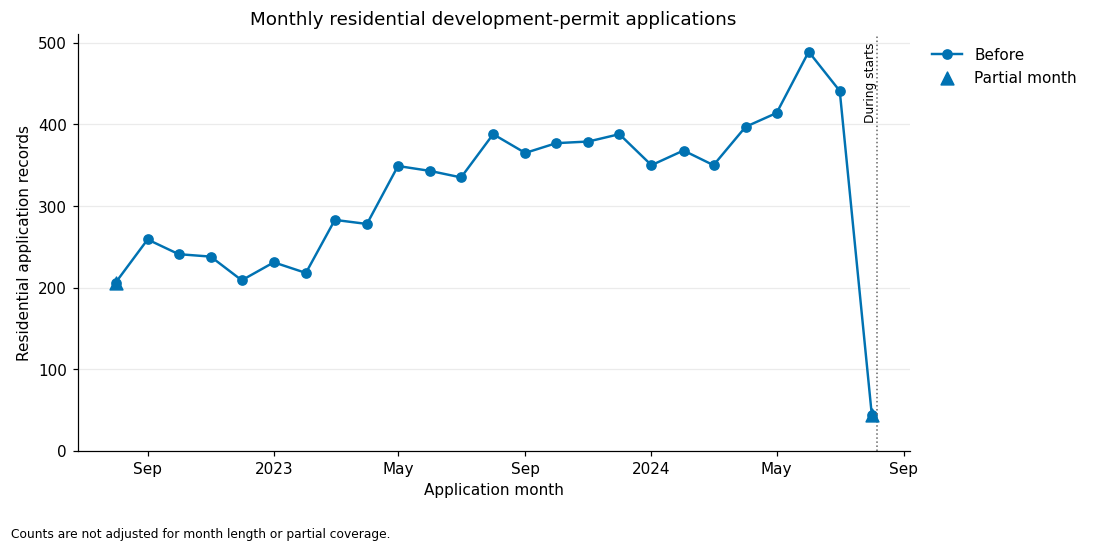

In [17]:
INCLUDE_PARTIAL_SEASONS = False
SEASON_YEAR_METRIC = "PermitCount"
chart_factory = ChartFactory()
figures = {}
covered_start = covered_periods[0].start
covered_end = min(covered_periods[0].end, observation_end)
policy_boundaries = {
    f"{period.name} starts": period.start
    for period in config.periods[1:]
    if covered_start <= period.start <= covered_end + timedelta(days=1)
}
figures["monthly_volume"] = chart_factory.monthly_volume(
    analysis_tables["monthly_volume"], policy_boundaries=policy_boundaries,
)
image_buffer = BytesIO()
figures["monthly_volume"].savefig(image_buffer, format="png", dpi=110, bbox_inches="tight")
display(Image(data=image_buffer.getvalue()))

## Month × Year heatmap

Rows are **Jan–Dec** and columns are **calendar years**. Cell values are residential DP counts. Gray/dash cells mean no supplied data, not zero. A recorded zero is colored and labelled 0. `*` marks partial coverage and `?` unknown coverage. The current data support only a Before panel.

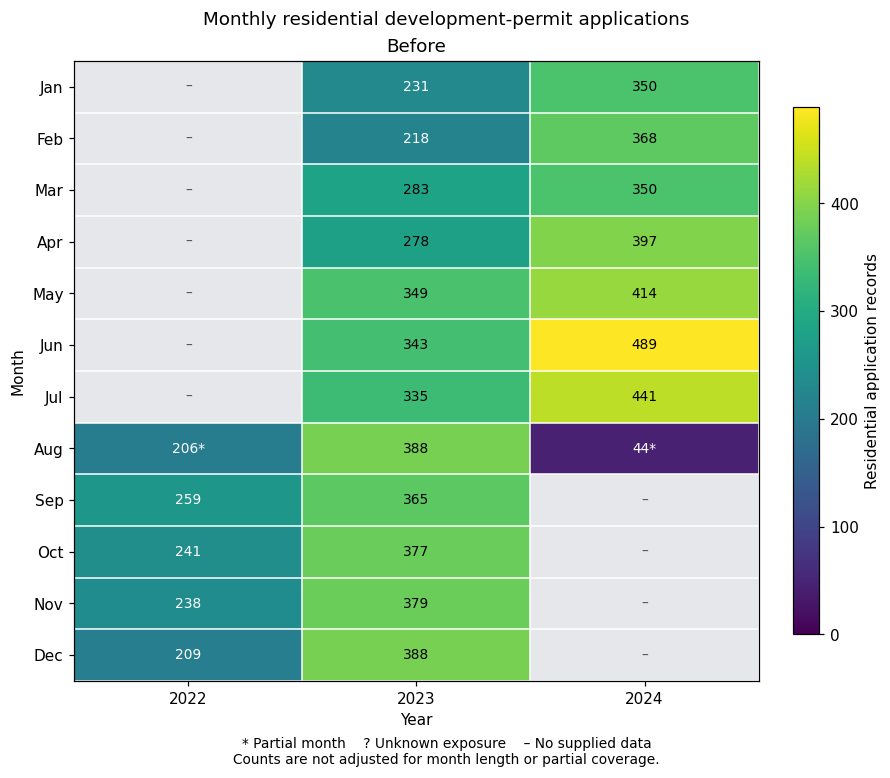

In [18]:
figures["month_year"] = chart_factory.monthly_heatmap(analysis_tables["monthly_volume"])
image_buffer = BytesIO()
figures["month_year"].savefig(image_buffer, format="png", dpi=110, bbox_inches="tight")
display(Image(data=image_buffer.getvalue()))

## Season × Year heatmap

Rows are **Winter, Spring, Summer, Fall** and columns are **season years**. Winter December 2023–February 2024 belongs to 2024. The metric is selected above; the default is DP count. Rates are calculated from counts and exposure, not from averaging existing rate values.

Gray cells may be outside the loaded coverage or excluded partial/unknown seasons. They do not establish zero seasonal activity.

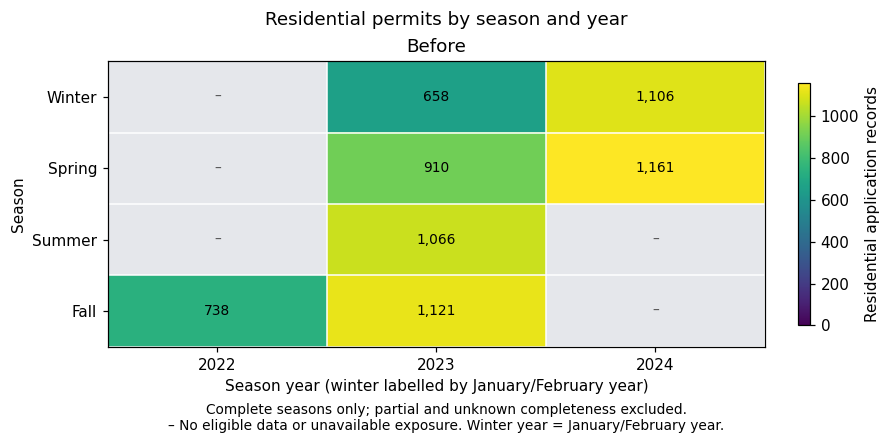

In [19]:
figures["season_year"] = chart_factory.seasonal_year_heatmap(
    analysis_tables["seasonal_summary"], metric=SEASON_YEAR_METRIC,
    include_partial=INCLUDE_PARTIAL_SEASONS,
)
image_buffer = BytesIO()
figures["season_year"].savefig(image_buffer, format="png", dpi=110, bbox_inches="tight")
display(Image(data=image_buffer.getvalue()))

## Season × Policy Period heatmap

Rows are **Winter, Spring, Summer, Fall** and columns are policy periods. Each cell pools eligible counts and exposure: **sum(PermitCount) / sum(ExposureDays) × 30**. It is not an average of seasonal rates.

This pinned snapshot produces only a **Before** column. A During comparison requires separately verified coverage for that period; the notebook does not infer it. Rates adjust exposure length, not confounding.

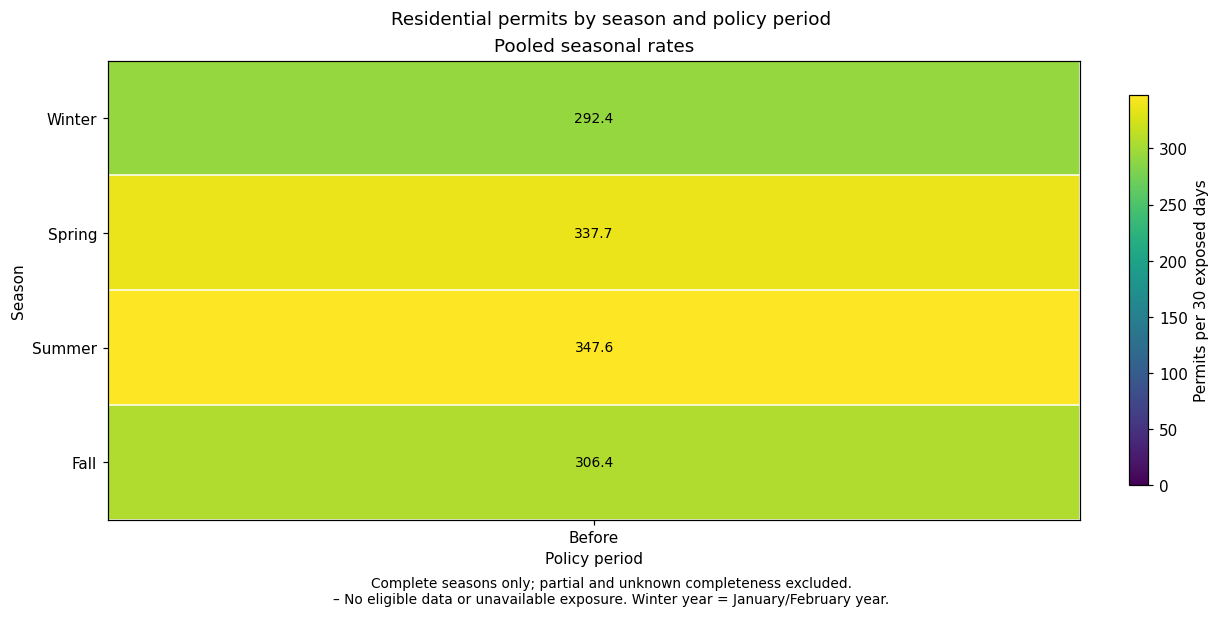

In [20]:
# A wider canvas keeps long notes and season labels readable for this one-column view.
figures["season_period"] = ChartFactory({"figure.figsize": (11, 5.5)}).seasonal_period_heatmap(
    analysis_tables["seasonal_summary"], include_partial=INCLUDE_PARTIAL_SEASONS,
)
image_buffer = BytesIO()
figures["season_period"].savefig(image_buffer, format="png", dpi=110, bbox_inches="tight")
display(Image(data=image_buffer.getvalue()))

## Optional exploratory exports

Set `EXPORT_EXPLORATORY_OUTPUTS=True` only when you want notebook artifacts. The default writes nothing. Enabled exports go to the separate `reports/notebook_before/` directory, using configured table formats and labels; figures are PNGs. Overwrite is disabled so prior notebook artifacts are preserved.

These are exploratory products: validation remains collect-only, source warnings need investigation, and no full run manifest or Power BI agreement is certified. The in-memory summaries above are available regardless of this switch.

In [21]:
EXPORT_EXPLORATORY_OUTPUTS = False
notebook_output_paths = {}
if EXPORT_EXPLORATORY_OUTPUTS:
    notebook_output_dir = ROOT / "reports" / "notebook_before"
    notebook_exporter = PowerBIExporter(
        output_repository=OutputRepository(notebook_output_dir / "tables", overwrite_outputs=False),
        output_formats=config.processed_output_formats,
        base_name="before_exploration",
        output_names=config.raw.get("outputs", {}),
    )
    notebook_output_paths = notebook_exporter.export(
        featured, analysis_tables,
        {"schema_validator": schema_issues, "data_quality_validator": quality_results,
         "classification_validator": classification_validation},
    )
    # The chart API replaces destinations, so use a fresh directory for each export.
    from uuid import uuid4
    figure_directory = notebook_output_dir / "figures" / uuid4().hex
    for name, figure in figures.items():
        notebook_output_paths[f"chart_{name}"] = chart_factory.save(figure, figure_directory / f"{name}.png")
    display(pd.DataFrame([{"output": name, "path": str(path.relative_to(ROOT))}
                          for name, path in notebook_output_paths.items()]))
else:
    print("Exploratory exports disabled; no table or chart files written.")
assert_frame_equal(featured, analysis_input)
assert_frame_equal(raw, raw_before)

Exploratory exports disabled; no table or chart files written.


## Findings, visualization plan, and remaining work

Use refreshed results above, not historical counts copied into prose. Successful cell execution and matching totals do not establish classification accuracy or policy effects.

| Supporting question | Available here | Remaining work |
|---|---|---|
| Monthly residential volume | Line chart and Month × Year heatmap | During coverage; period-average lines |
| Development-type mix | Residential counts/shares | Power BI stacked/grouped bars and comparison |
| Community change | No cross-period comparison from this snapshot | Verified During coverage and Power BI ranked bars/map |
| Typical processing time | Residential median, quartiles, IQR and eligibility summaries | Box plots/distributions and period comparison; minimum follow-up policy |
| Rezoning-relevant share | Counts/shares with residential denominator | Power BI comparison; this flag is not an official City designation |
| Seasonal activity | Season × Year and Season × Policy Period heatmaps | Grouped seasonal bars and comparison coverage |

The package also has a sensitivity runner, a Power BI table exporter, and a passing offline CLI smoke test with synthetic records. Study-specific sensitivity scenarios, minimum-follow-up eligibility, fatal-validation policy, full provenance, automatic CLI charts, and actual Power BI reconciliation remain unfinished.

Inspect missing data, unmatched/review classifications, and source evidence before accepting findings. No independent human-label accuracy study is performed here. Raw snapshots stay in the ignored data directory. Review public source text and notebook outputs before sharing.